In [1]:
import numpy as np 
import pandas as pd

import os
import cv2 as cv
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
all_0 = "C:/Users/SNEKHA/Desktop/C-NMC_Leukemia/training_data/fold_0/all"
all_1 = "C:/Users/SNEKHA/Desktop/C-NMC_Leukemia/training_data/fold_1/all"
all_2 = "C:/Users/SNEKHA/Desktop/C-NMC_Leukemia/training_data/fold_2/all"

hem_0 = "C:/Users/SNEKHA/Desktop/C-NMC_Leukemia/training_data/fold_0/hem"
hem_1 = "C:/Users/SNEKHA/Desktop/C-NMC_Leukemia/training_data/fold_1/hem"
hem_2 = "C:/Users/SNEKHA/Desktop/C-NMC_Leukemia/training_data/fold_2/hem"

In [3]:
def get_path_image(folder):
    image_paths = []
    image_fnames = os.listdir(folder) 
    for img_id in range(len(image_fnames)):
        img = os.path.join(folder,image_fnames[img_id])
        image_paths.append(img)
    
    return image_paths

In [4]:
img_data = []

for i in [all_0,all_1,all_2,hem_0,hem_1,hem_2]:
    paths = get_path_image(i)
    img_data.extend(paths)
print(len(img_data))

10661


In [5]:
data = {"img_data":img_data,
        "labels":[np.nan for x in range(len(img_data))]}

data = pd.DataFrame(data) 

In [6]:
data["labels"][0:7272] = 1 # ALL
data["labels"][7272:10661] = 0 # HEM

C:\Users\SNEKHA\AppData\Local\Temp\ipykernel_19224\2481703241.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["labels"][0:7272] = 1 # ALL
C:\Users\SNEKHA\AppData\Local\Temp\ipykernel_19224\2481703241.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["labels"][7272:10661] = 0 # HEM


In [7]:
data["labels"] = data["labels"].astype("int64")

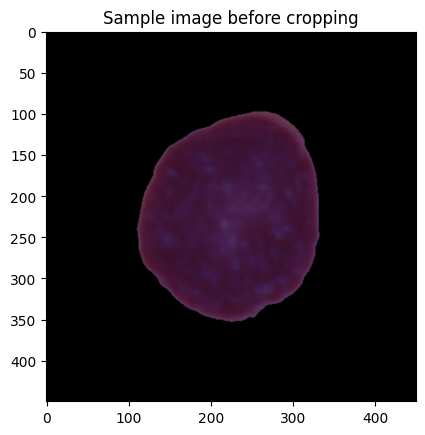

In [8]:
image = cv.imread(data["img_data"][1000])
plt.imshow(image)
plt.title("Sample image before cropping")
plt.show()

In [9]:
img_list = []
for i in range(len(img_data)):
    image = cv.imread(data["img_data"][i])
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    thresh = cv.threshold(gray, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)[1]

    result = cv.bitwise_and(image, image, mask=thresh)
    result[thresh==0] = [255,255,255] 
    (x, y, z_) = np.where(result > 0)
    mnx = (np.min(x))
    mxx = (np.max(x))
    mny = (np.min(y))
    mxy = (np.max(y))
    crop_img = image[mnx:mxx,mny:mxy,:]
    crop_img_r = cv.resize(crop_img, (224,224))
    img_list.append(crop_img_r)

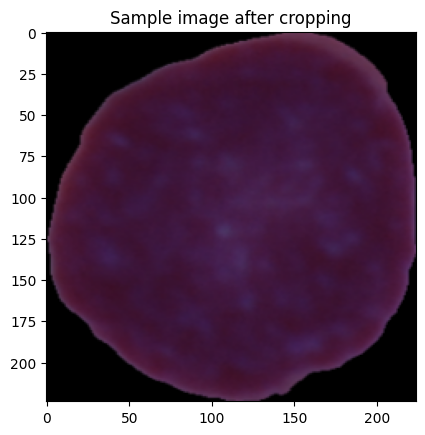

In [10]:
plt.imshow(img_list[1000])
plt.title("Sample image after cropping")
plt.show()

In [11]:
from tensorflow.keras.applications import ResNet50, ResNet101
from keras.applications.vgg19 import VGG19
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.applications.resnet50 import preprocess_input

In [12]:
def feature_extract(model):
    if model == "VGG19": model = VGG19(weights='imagenet',include_top=False, pooling="avg")
    elif model == "ResNet50": model = ResNet50(weights='imagenet',include_top=False,pooling="avg")
    elif model == "ResNet101": model = ResNet101(weights='imagenet',include_top=False,pooling="avg")
    return model

In [13]:
model = feature_extract("ResNet50") # or "VGG19", "ResNet101"

In [ ]:
features_list = []
for i in range(len(img_list)):
            
    image = img_list[i].reshape(-1, 224, 224, 3) 
    image = preprocess_input(image)
    
    """
    # Reshaping when VGG19 model is selected
    features = model.predict(image).reshape(512,)
    """

    #Reshaping  when ResNet50 or ResNet101 model is selected
    features = model.predict(image).reshape(2048,)
    
    features_list.append(features)

1/1 [==============================] - 1s 502ms/step


1/1 [==============================] - 3s 3s/step


1/1 [==============================] - 3s 3s/step


1/1 [==============================] - 3s 3s/step


1/1 [==============================] - 3s 3s/step


...

1/1 [==============================] - 4s 4s/step


1/1 [==============================] - 4s 4s/step


1/1 [==============================] - 4s 4s/step


1/1 [==============================] - 6s 6s/step


1/1 [==============================] - 6s 6s/step


In [15]:
features_df = pd.DataFrame(features_list)

In [16]:
features_df["labels"] = data["labels"]

In [17]:
x = features_df.drop(['labels'], axis = 1)
y = features_df.loc[:,"labels"].values

In [18]:
x

,0,1,2,3,4,5,6,7,8,9,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
0,5.253783,0.042580,0.051578,0.008029,0.057129,0.004375,0.227441,0.003590,0.005153,0.012571,...,0.561743,0.071850,0.011782,1.103318,0.290165,0.000000,0.491152,0.112431,0.000000,0.310525
1,8.079423,0.011574,0.053684,0.186905,0.000000,0.000000,0.042724,0.000000,0.574390,0.006339,...,0.209751,0.000000,0.000000,1.683905,0.019044,0.000000,0.020532,0.196671,0.081518,0.548087
2,6.266923,0.219213,0.018837,0.008474,0.000000,0.000000,0.224284,0.000000,0.000000,0.012756,...,0.137901,0.000000,0.000000,0.857915,0.159714,0.044442,0.702736,0.286233,0.070878,0.547750
3,6.486918,0.000000,0.020409,0.164188,0.000000,0.039742,0.098523,0.000000,0.136671,0.093839,...,0.383021,0.041494,0.000000,2.700690,0.249594,0.000000,0.152288,0.462613,0.330928,0.708187
4,5.148223,0.060939,0.000000,0.106593,0.000000,0.036498,0.074916,0.095883,0.034331,0.008917,...,0.175660,0.030387,0.190983,0.357074,0.000000,0.015142,0.291253,0.187770,0.045915,0.046781
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10656,5.135459,0.023519,0.000000,0.013403,0.095962,0.044262,0.067926,0.006756,0.088878,0.000000,...,0.048080,0.036390,0.021044,0.119651,0.045240,0.000000,0.611429,0.220862,0.202260,1.137161
10657,5.458828,0.028126,0.000000,0.173168,0.000000,0.006622,0.014663,0.024785,0.046513,0.125333,...,0.638946,0.064940,0.215364,0.566119,0.000000,0.000000,0.363782,0.380672,1.268512,0.600716
10658,5.933909,0.000000,0.000000,0.069616,0.000000,0.110708,0.000000,0.000000,0.008634,0.000000,...,0.152811,0.000000,0.011421,0.638716,0.095322,0.000000,0.569343,0.919506,0.474505,0.909486
10659,5.647941,0.059169,0.000000,0.116159,0.007541,0.000000,0.112060,0.000000,0.081253,0.293994,...,1.008240,0.030306,0.088561,0.514058,0.000000,0.000000,0.012645,0.703623,0.492333,1.778769


In [19]:
print(f"Number of features before feature selection: {x.shape[1]}")

Number of features before feature selection: 2048


In [20]:

y

array([1, 1, 1, ..., 0, 0, 0], dtype=int64)

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x)
x_ = scaler.transform(x)

In [22]:
x_ = pd.DataFrame(x_)

In [23]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

def anova_fs():
    
    selector = SelectKBest(f_classif, k=500) # k is number of features
    selector.fit(x_, y)

    cols = selector.get_support(indices=True)
    anova_x = x_[cols]
    return anova_x

In [24]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

def RFE_fs():
    rfe_selector = RFE(estimator=RandomForestClassifier())
    rfe_selector.fit(x_, y)
    
    rfe_support = rfe_selector.get_support()
    rfe_feature = x_.loc[:,rfe_support].columns.tolist()
    
    rfe_x = x_[rfe_feature]
    return rfe_x

In [25]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

def rf_fs():
    embeded_rf_selector = SelectFromModel(RandomForestClassifier(n_estimators=200, random_state=5), threshold='1.25*median')
    embeded_rf_selector.fit(x, y)
    
    embeded_rf_support = embeded_rf_selector.get_support()
    embeded_rf_feature = x.loc[:,embeded_rf_support].columns.tolist()
    
    rf_x = x[embeded_rf_feature]
    return rf_x

In [26]:
fs_x = rf_fs() # feature selection methods "anova_fs", "RFE_fs"

In [27]:
print(f"Number of features after feature selection: {fs_x.shape[1]}")

Number of features after feature selection: 630


In [28]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(fs_x, y, test_size = 0.2, random_state = 42)

In [29]:
from sklearn.model_selection import cross_val_score,cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score,precision_score,recall_score,accuracy_score
from sklearn.model_selection import GridSearchCV

KNN

In [30]:
neig = np.arange(1, 25)
train_accuracy = []
test_accuracy = []

for i, k in enumerate(neig):

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train,y_train)
    prediction_ = knn.predict(x_test)
    train_accuracy.append(knn.score(x_train, y_train))
    test_accuracy.append(knn.score(x_test, y_test))
    
print("Best accuracy is {} with K = {}".format(np.max(test_accuracy),1+test_accuracy.index(np.max(test_accuracy))))

Best accuracy is 0.8288795124238162 with K = 9


In [31]:
knn = KNeighborsClassifier(n_neighbors=17)
knn.fit(x_train,y_train)
predicted = knn.predict(x_test)
score = knn.score(x_test, y_test)
knn_score_ = np.mean(score)

print('Accuracy : %.3f' % (knn_score_))

Accuracy : 0.827


In [32]:
p=precision_score(y_test, predicted) 
print('Precision : %.3f' % (p))

r=recall_score(y_test, predicted) 
print('Recall : %.3f' % (r))

f1=f1_score(y_test, predicted) 
print('F1-score: %.3f' % (f1))

f1_w=f1_score(y_test, predicted, average='weighted') 
print('Weighted f1-score: %.3f' % (f1_w))

Precision : 0.828
Recall : 0.943
F1-score: 0.881
Weighted f1-score: 0.817


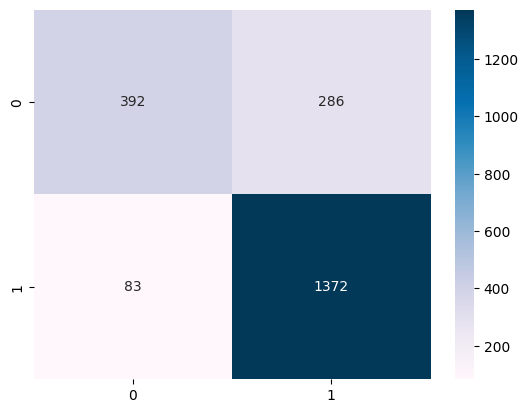

In [33]:
cf_matrix = confusion_matrix(y_test, predicted)
sns.heatmap(cf_matrix, cmap="PuBu", annot=True, fmt='.0f')
plt.show()

SVM

In [30]:

param_grid_svm = {'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'kernel': ['rbf', 'poly']}
 
SVM_grid = GridSearchCV(svm.SVC(), param_grid_svm, cv=5)
SVM_grid.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf', 'poly']})

In [31]:
print(SVM_grid.best_params_)
 
print(SVM_grid.best_estimator_)

{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
SVC(C=10, gamma=0.01)


In [36]:
svm_clf = svm.SVC(C=10, gamma=0.01, kernel='rbf')
svm_clf.fit(x_train,y_train)
predicted = svm_clf.predict(x_test)
score = svm_clf.score(x_test, y_test)
svm_score_ = np.mean(score)

print('Accuracy : %.3f' % (svm_score_))

Accuracy : 0.901


In [37]:
p=precision_score(y_test, predicted) 
print('precision : %.3f' % (p))

r=recall_score(y_test, predicted) 
print('recall : %.3f' % (r))

f1=f1_score(y_test, predicted) 
print('f1-score: %.3f' % (f1))


f1_w=f1_score(y_test, predicted, average='weighted') 
print('weighted f1-score: %.3f' % (f1_w))

precision : 0.905
recall : 0.955
f1-score: 0.929
weighted f1-score: 0.899


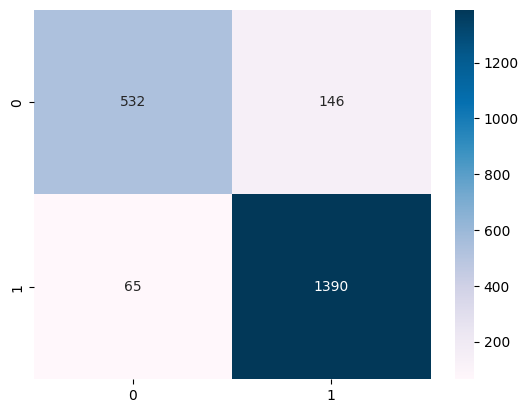

In [38]:
cf_matrix = confusion_matrix(y_test, predicted)
sns.heatmap(cf_matrix, cmap="PuBu", annot=True, fmt='.0f')
plt.show()

In [44]:

param_grid_svm = {'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'kernel': ['rbf']}
 
SVM_grid = GridSearchCV(svm.SVC(), param_grid_svm, refit=True,verbose=3)
SVM_grid.fit(x_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.682 total time=  26.6s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.682 total time=  27.3s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.682 total time=  26.9s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.682 total time=  26.3s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.682 total time=  27.9s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.682 total time=  31.8s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.682 total time=  29.2s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.682 total time=  30.6s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.682 total time=  29.6s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.682 total time=  29.7s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.825 total time=  17.3s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [47]:
print(SVM_grid.best_params_)
 
print(SVM_grid.best_estimator_)

{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
SVC(C=10, gamma=0.01)


In [48]:
svm_clf = svm.SVC(C=10, gamma=0.01, kernel='rbf')
svm_clf.fit(x_train,y_train)
predicted = svm_clf.predict(x_test)
score = svm_clf.score(x_test, y_test)
svm_score_ = np.mean(score)

print('Accuracy : %.3f' % (svm_score_))

Accuracy : 0.901


In [30]:

param_grid_svm = {'C': [0.1, 1, 10, 100],
              'gamma': [1, 0.1, 0.01, 0.001],
              'kernel': ['rbf','poly','sigmoid']}
 
SVM_grid = GridSearchCV(svm.SVC(), param_grid_svm, refit=True,verbose=2)
SVM_grid.fit(x_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=  27.9s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=  26.7s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=  26.2s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=  26.7s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=  26.7s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=  15.5s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=  15.3s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=  15.5s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=  15.7s
[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=  14.7s
[CV] END .....................C=0.1, gamma=1, kernel=sigmoid; total time=  15.0s
[CV] END .....................C=0.1, gamma=1, k

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['rbf', 'poly', 'sigmoid']},
             verbose=2)

In [31]:
print(SVM_grid.best_params_)
 
print(SVM_grid.best_estimator_)

{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
SVC(C=10, gamma=0.01)


In [74]:
svm_clf = svm.SVC(C=10, gamma=0.005 ,kernel='rbf')
svm_clf.fit(x_train,y_train)
predicted = svm_clf.predict(x_test)
score = svm_clf.score(x_test, y_test)
svm_score_ = np.mean(score)

print('Accuracy : %.3f' % (svm_score_))

Accuracy : 0.902


In [75]:
svm_clf = svm.SVC(C=10, gamma=0.5 ,kernel='rbf')
svm_clf.fit(x_train,y_train)
predicted = svm_clf.predict(x_test)
score = svm_clf.score(x_test, y_test)
svm_score_ = np.mean(score)

print('Accuracy : %.3f' % (svm_score_))

Accuracy : 0.702


In [37]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
svc=SVC()

In [38]:
param_grid_svm = {'C': [0.1, 1.0, 10.0, 100.0,1000.0,10000.0,100000.0],
              'gamma': [0.00001, 0.0001, 0.001, 0.01,0.1,1.0],
               'kernel': ['rbf','sigmoid','poly']}
SVM_grid = RandomizedSearchCV(estimator=svc,param_distributions= param_grid_svm, cv=5)
SVM_grid.fit(x_train, y_train)

RandomizedSearchCV(cv=5, estimator=SVC(),
                   param_distributions={'C': [0.1, 1.0, 10.0, 100.0, 1000.0,
                                              10000.0, 100000.0],
                                        'gamma': [1e-05, 0.0001, 0.001, 0.01,
                                                  0.1, 1.0],
                                        'kernel': ['rbf', 'sigmoid', 'poly']})

In [39]:
print(SVM_grid.best_params_)
  
print(SVM_grid.best_estimator_)

{'kernel': 'rbf', 'gamma': 1e-05, 'C': 10000.0}
SVC(C=10000.0, gamma=1e-05)


In [43]:
svm_clf = svm.SVC(C=10000.0, gamma=1e-05, kernel='rbf')
svm_clf.fit(x_train,y_train)
predicted = svm_clf.predict(x_test)
score = svm_clf.score(x_test, y_test)
svm_score_ = np.mean(score)

print('Accuracy : %.3f' % (svm_score_))

Accuracy : 0.862


In [ ]:

param_grid_svm = {'C': [0.1, 1, 10, 100, 1000,10000,100000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001,0.00001,0.000001],
              'kernel': ['rbf','sigmoid', 'poly']}
 
SVM_grid = RandomizedSearchCV(svm.SVC(), param_grid_svm, cv=5)
SVM_grid.fit(x_train, y_train)

In [ ]:
param_grid_svm = {'C': [0.1, 0.8, 0.9, 1,1.1,1.2,1.3,1.4],
              'gamma': [0.1, 0.8, 0.9, 1,1.1,1.2,1.3,1.4],
               'kernel': ['linear','rbf']}
 
SVM_grid = GridSearchCV(svm.SVC(), param_grid_svm, cv=10)
SVM_grid.fit(x_train, y_train)

In [ ]:
print(SVM_grid.best_params_)
  
print(SVM_grid.best_estimator_)

In [ ]:
svm_clf = svm.SVC(C=10, gamma=0.01, kernel='rbf')
svm_clf.fit(x_train,y_train)
predicted = svm_clf.predict(x_test)
score = svm_clf.score(x_test, y_test)
svm_score_ = np.mean(score)

print('Accuracy : %.3f' % (svm_score_))

# Hyperparameter Tuning Using Grid Search

In [40]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
#from hyperopt import tpe, STATUS_OK, Trials, hp, fmin, STATUS_OK, space_eval

In [41]:
# List of C values
C_range = np.logspace(-1, 1, 3)
print(f'The list of values for C are {C_range}')

# List of gamma values
gamma_range = np.logspace(-1, 1, 3)
print(f'The list of values for gamma are {gamma_range}')

The list of values for C are [ 0.1  1.  10. ]
The list of values for gamma are [ 0.1  1.  10. ]


In [42]:
# Define the search space
param_grid = { 
    # Regularization parameter.
    "C": C_range,
    # Kernel type
    "kernel": ['rbf', 'poly'],
    # Gamma is the Kernel coefficient for ‘rbf’, ‘poly’ and ‘sigmoid’.
    "gamma": gamma_range.tolist()+['scale', 'auto']
    }

# Set up score
scoring = ['accuracy']

# Set up the k-fold cross-validation
kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)

In [43]:
# Define grid search
grid_search = GridSearchCV(estimator=svm_clf, 
                           param_grid=param_grid, 
                           scoring=scoring, 
                           refit='accuracy', 
                           n_jobs=-1, 
                           cv=kfold, 
                           verbose=0)

# Fit grid search
grid_result = grid_search.fit(x_train, y_train)

# Print grid search summary
grid_result

GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=0, shuffle=True),
             estimator=SVC(C=100, gamma=0.01), n_jobs=-1,
             param_grid={'C': array([ 0.1,  1. , 10. ]),
                         'gamma': [0.1, 1.0, 10.0, 'scale', 'auto'],
                         'kernel': ['rbf', 'poly']},
             refit='accuracy', scoring=['accuracy'])

In [44]:
# Print the best accuracy score for the training dataset
print(f'The best accuracy score for the training dataset is {grid_result.best_score_:.4f}')

# Print the hyperparameters for the best score
print(f'The best hyperparameters are {grid_result.best_params_}')

# Print the best accuracy score for the testing dataset
print(f'The accuracy score for the testing dataset is {grid_search.score(x_test, y_test):.4f}')

The best accuracy score for the training dataset is 0.8738
The best hyperparameters are {'C': 10.0, 'gamma': 'auto', 'kernel': 'rbf'}
The accuracy score for the testing dataset is 0.8819


# Hyperparameter Tuning Using Random Search

In [45]:
# List of C values
C_range = np.logspace(-10, 10, 21)
print(f'The list of values for C are {C_range}')

# List of gamma values
gamma_range = np.logspace(-10, 10, 21)
print(f'The list of values for gamma are {gamma_range}')

The list of values for C are [1.e-10 1.e-09 1.e-08 1.e-07 1.e-06 1.e-05 1.e-04 1.e-03 1.e-02 1.e-01
 1.e+00 1.e+01 1.e+02 1.e+03 1.e+04 1.e+05 1.e+06 1.e+07 1.e+08 1.e+09
 1.e+10]
The list of values for gamma are [1.e-10 1.e-09 1.e-08 1.e-07 1.e-06 1.e-05 1.e-04 1.e-03 1.e-02 1.e-01
 1.e+00 1.e+01 1.e+02 1.e+03 1.e+04 1.e+05 1.e+06 1.e+07 1.e+08 1.e+09
 1.e+10]


In [46]:
# Define the search space
param_grid = { 
    # Regularization parameter.
    "C": C_range,
    # Kernel type
    "kernel": ['rbf', 'poly'],
    # Gamma is the Kernel coefficient for ‘rbf’, ‘poly’ and ‘sigmoid’.
    "gamma": gamma_range.tolist()+['scale', 'auto']
    }

# Set up score
scoring = ['accuracy']

# Set up the k-fold cross-validation
kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)

# Define random search
random_search = RandomizedSearchCV(estimator=svm_clf, 
                           param_distributions=param_grid, 
                           n_iter=100,
                           scoring=scoring, 
                           refit='accuracy', 
                           n_jobs=-1, 
                           cv=kfold, 
                           verbose=0)

# Fit grid search
random_result = random_search.fit(x_train, y_train)

# Print grid search summary
random_result

C:\Users\SNEKHA\anaconda3\envs\keras_env\Lib\site-packages\sklearn\model_selection\_validation.py:542: FitFailedWarning: 
3 fits failed out of a total of 300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\SNEKHA\anaconda3\envs\keras_env\Lib\site-packages\sklearn\model_selection\_validation.py", line 890, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\SNEKHA\anaconda3\envs\keras_env\Lib\site-packages\sklearn\base.py", line 1351, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\SNEKHA\anaconda3\envs\keras_env\Lib\site-packages\sklea

RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=0, shuffle=True),
                   estimator=SVC(C=100, gamma=0.01), n_iter=100, n_jobs=-1,
                   param_distributions={'C': array([1.e-10, 1.e-09, 1.e-08, 1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03,
       1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04, 1.e+05,
       1.e+06, 1.e+07, 1.e+08, 1.e+09, 1.e+10]),
                                        'gamma': [1e-10, 1e-09, 1e-08, 1e-07,
                                                  1e-06, 1e-05, 0.0001, 0.001,
                                                  0.01, 0.1, 1.0, 10.0, 100.0,
                                                  1000.0, 10000.0, 100000.0,
                                                  1000000.0, 10000000.0,
                                                  100000000.0, 1000000000.0,
                                                  10000000000.0, 'scale',
                                                  'auto'],
                                        'kernel': ['rbf', 'poly']},
                   refit='accuracy', scoring=['accuracy'])

In [47]:
# Print the best accuracy score for the training dataset
print(f'The best accuracy score for the training dataset is {random_result.best_score_:.4f}')

# Print the hyperparameters for the best score
print(f'The best hyperparameters are {random_result.best_params_}')

# Print the best accuracy score for the testing dataset
print(f'The accuracy score for the testing dataset is {random_search.score(x_test, y_test):.4f}')

The best accuracy score for the training dataset is 0.8705
The best hyperparameters are {'kernel': 'poly', 'gamma': 0.001, 'C': 10.0}
The accuracy score for the testing dataset is 0.8800


# Hyperparameter Tuning Using Bayesian Optimization

In [ ]:
param_grid_svm = {'C': [0.1, 0.8, 0.9, 1,1.1,1.2,1.3,1.4],
              'gamma': [0.1, 0.8, 0.9, 1,1.1,1.2,1.3,1.4],
              'kernel': ['linear','rbf']}
 
SVM_grid = GridSearchCV(svm.SVC(), param_grid_svm, cv=10)
SVM_grid.fit(x_train, y_train)

In [ ]:
print(SVM_grid.best_params_)
 
print(SVM_grid.best_estimator_)

In [ ]:
svm_clf = svm.SVC(C=100, gamma=0.01, kernel='rbf')
svm_clf.fit(x_train,y_train)
predicted = svm_clf.predict(x_test)
score = svm_clf.score(x_test, y_test)
svm_score_ = np.mean(score)

print('Accuracy : %.3f' % (svm_score_))

In [40]:
param_grid_rf = { 
    'n_estimators': [200, 500],
    'max_depth' : [4,5,6,7,8]}

RF_grid = GridSearchCV(estimator=RandomForestClassifier(), param_grid=param_grid_rf, cv= 5)
RF_grid.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [4, 5, 6, 7, 8],
                         'n_estimators': [200, 500]})

In [41]:
print(RF_grid.best_params_)

{'max_depth': 8, 'n_estimators': 200}


In [42]:
r_forest = RandomForestClassifier(500,max_depth=8, random_state=5)
r_forest.fit(x_train,y_train)
predicted = r_forest.predict(x_test)
score = r_forest.score(x_test, y_test)
rf_score_ = np.mean(score)

print('Accuracy : %.3f' % (rf_score_))

Accuracy : 0.822


In [43]:
p=precision_score(y_test, predicted) 
print('precision : %.3f' % (p))

r=recall_score(y_test, predicted) 
print('recall : %.3f' % (r))

f1=f1_score(y_test, predicted) 
print('f1-score: %.3f' % (f1))

f1_w=f1_score(y_test, predicted, average='weighted') 
print('weighted f1-score: %.3f' % (f1_w))

precision : 0.816
recall : 0.954
f1-score: 0.880
weighted f1-score: 0.810


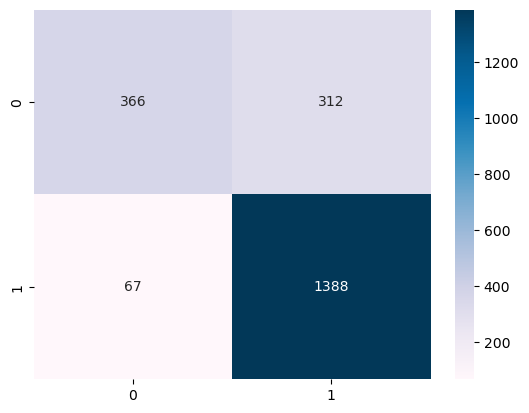

In [44]:
cf_matrix = confusion_matrix(y_test, predicted)
sns.heatmap(cf_matrix, cmap="PuBu", annot=True, fmt='.0f')
plt.show()

In [45]:
nb_model = GaussianNB()
nb_model.fit(x_train,y_train)
predicted = nb_model.predict(x_test)
score = nb_model.score(x_test, y_test)
nb_score_ = np.mean(score)

print('Accuracy : %.3f' % (nb_score_))

Accuracy : 0.762


In [46]:
p=precision_score(y_test, predicted) 
print('precision : %.3f' % (p))

r=recall_score(y_test, predicted) 
print('recall : %.3f' % (r))

f1=f1_score(y_test, predicted) 
print('f1-score: %.3f' % (f1))

f1_w=f1_score(y_test, predicted, average='weighted') 
print('weighted f1-score: %.3f' % (f1_w))

precision : 0.846
recall : 0.795
f1-score: 0.820
weighted f1-score: 0.765


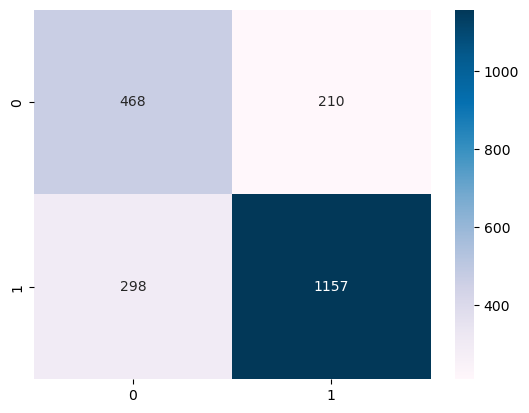

In [47]:
cf_matrix = confusion_matrix(y_test, predicted)
sns.heatmap(cf_matrix, cmap="PuBu", annot=True, fmt='.0f')
plt.show()

In [ ]:
# XGBoost
import xgboost as xgb
params_xgb ={'n_estimators': 500,
            'max_depth': 16}

model_xgb = xgb.XGBClassifier(**params_xgb)
model_xgb.fit(x_train,y_train)
predicted = model_xgb.predict(x_test)
score =model_xgb.score(x_test, y_test)
xgb_score_ = np.mean(score)

print('Accuracy : %.3f' % (xgb_score_))